# **Project Title :** AI-Powered IoT Network Anomaly Detection and Investigation Platform


## Dataset Information
| Item                    | Details                                              |
|-------------------------|------------------------------------------------------|
| **Dataset Name**        | CICIoT2023                                           |
| **Source**              | Canadian Institute for Cybersecurity (CIC)           |
| **Kaggle Dataset**      | [himadri07/ciciot2023](https://www.kaggle.com/datasets/himadri07/ciciot2023) |
| **Train Shape**         | 5,491,971 rows × 47 columns                          |
| **Validation Shape**    | 1,176,851 rows × 47 columns                          |
| **Test Shape**          | 1,176,851 rows × 47 columns                          |
| **Total Features**      | 46 network flow features + 1 label                   |
| **Attack Types**        | 33 different attacks (DDoS, DoS, Mirai, Recon, Spoofing, Brute Force, Web-based) |
| **Main Task**           | Unsupervised Anomaly Detection                       |

---

# Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [4]:
data_path = "/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23"
train_path = data_path + "/train/train.csv"
test_path = data_path + "/test/test.csv"
validation_path = data_path + "/validation/validation.csv"
print("Trainning Dataset: " + train_path)
print("Testing Dataset: " + test_path)
print("Validation Dataset: " + validation_path)

Trainning Dataset: /kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train/train.csv
Testing Dataset: /kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/test/test.csv
Validation Dataset: /kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/validation/validation.csv


In [5]:
df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(validation_path)
df_test  = pd.read_csv(test_path)

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)
print("\nColumns:")
print(df_train.columns.tolist())

Train shape: (5491971, 47)
Validation shape: (1176851, 47)
Test shape: (1176851, 47)

Columns:
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


In [6]:
df_train.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491971 entries, 0 to 5491970
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             float64
 20  HTTPS            float64
 21  DNS              float64
 22  Telnet           float64
 23  SMTP             float64
 24  SSH              float64
 25  IRC              float64
 26  TCP              float64
 27  UDP         

# Exploratory Data Analysis

## Basic Overview

In [8]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Train shape      : {df_train.shape}")
print(f"Validation shape : {df_val.shape}")
print(f"Test shape       : {df_test.shape}")

print("\nColumn Names:")
print(df_train.columns.tolist())

print("\nData Types:")
print(df_train.dtypes.value_counts())

DATASET OVERVIEW
Train shape      : (5491971, 47)
Validation shape : (1176851, 47)
Test shape       : (1176851, 47)

Column Names:
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

Data Types:
float64    46
object      1
Name: count, dtype: int64


## Missing & Infinite Values

In [10]:
print("="*60)
print("MISSING & INFINITE VALUES CHECK & DUPLICATED")
print("="*60)

print("Missing values in Train:", df_train.isnull().sum().sum())
print("Infinite values in Train:", np.isinf(df_train.select_dtypes(include=[np.number])).sum().sum())
print(
    f"Duplicated values in Train: {df_train.duplicated().sum()} "
    f"- Percentage: {(df_train.duplicated().sum() / len(df_train)):.2%}"
)
print("\nMissing values per column (Top 10):")
print(df_train.isnull().sum().sort_values(ascending=False).head())

MISSING & INFINITE VALUES CHECK & DUPLICATED
Missing values in Train: 0
Infinite values in Train: 0
Duplicated values in Train: 134565 - Percentage: 2.45%

Missing values per column (Top 10):
flow_duration    0
Header_Length    0
Protocol Type    0
Duration         0
Rate             0
dtype: int64


## Phân tích label

In [12]:
# Target variable (label) distribution
print('='*60)
print('TARGET VARIABLE DISTRIBUTION')
print('='*60)

label_counts = df_train['label'].value_counts()
label_pct = df_train['label'].value_counts(normalize=True) * 100

# Create summary dataframe
label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage (%)': label_pct.round(2)
})

print(f'\nTotal unique labels: {len(label_counts)}')
print(f'\n{label_summary}')

TARGET VARIABLE DISTRIBUTION

Total unique labels: 34

                          Count  Percentage (%)
label                                          
DDoS-ICMP_Flood          848088           15.44
DDoS-UDP_Flood           637558           11.61
DDoS-TCP_Flood           528499            9.62
DDoS-PSHACK_Flood        481254            8.76
DDoS-SYN_Flood           478653            8.72
DDoS-RSTFINFlood         475441            8.66
DDoS-SynonymousIP_Flood  422083            7.69
DoS-UDP_Flood            390422            7.11
DoS-TCP_Flood            314174            5.72
DoS-SYN_Flood            237573            4.33
BenignTraffic            129538            2.36
Mirai-greeth_flood       116133            2.11
Mirai-udpplain           104814            1.91
Mirai-greip_flood         88821            1.62
DDoS-ICMP_Fragmentation   53046            0.97
MITM-ArpSpoofing          36316            0.66
DDoS-UDP_Fragmentation    34169            0.62
DDoS-ACK_Fragmentation    33581  

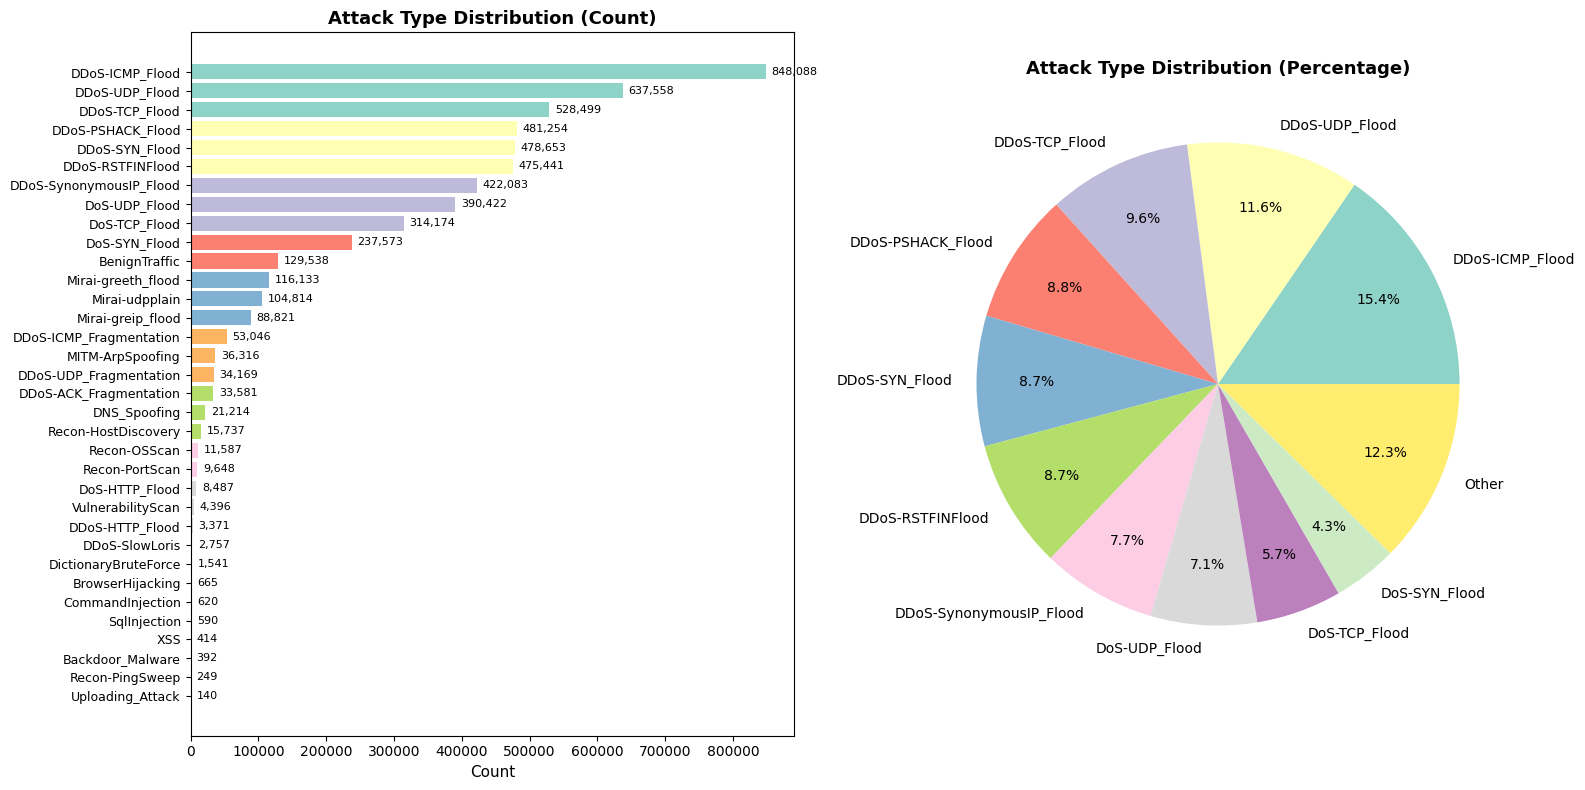


Plot saved to: plots/01_class_distribution.png


In [16]:
import os
os.makedirs('/kaggle/working/plots', exist_ok=True)

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Bar chart of class distribution
ax1 = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(label_counts)))
bars = ax1.barh(range(len(label_counts)), label_counts.values, color=colors)
ax1.set_yticks(range(len(label_counts)))
ax1.set_yticklabels(label_counts.index, fontsize=9)
ax1.set_xlabel('Count', fontsize=11)
ax1.set_title('Attack Type Distribution (Count)', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, label_counts.values)):
    ax1.text(count + label_counts.max()*0.01, i, f'{count:,}', va='center', fontsize=8)

# Plot 2: Pie chart
ax2 = axes[1]
top_10 = label_counts.head(10)
other = label_counts.iloc[10:].sum()
if other > 0:
    pie_data = pd.concat([top_10, pd.Series({'Other': other})])
else:
    pie_data = top_10

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax2.pie(pie_data.values, labels=pie_data.index,
                                    autopct='%1.1f%%', colors=colors_pie,
                                    pctdistance=0.75, labeldistance=1.1)
ax2.set_title('Attack Type Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPlot saved to: plots/01_class_distribution.png')

/tmp/ipykernel_58/593234392.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_labels.values, y=top_labels.index, palette="viridis")
/tmp/ipykernel_58/593234392.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=binary_counts.index, y=binary_counts.values, palette=["#2ecc71", "#e74c3c"])


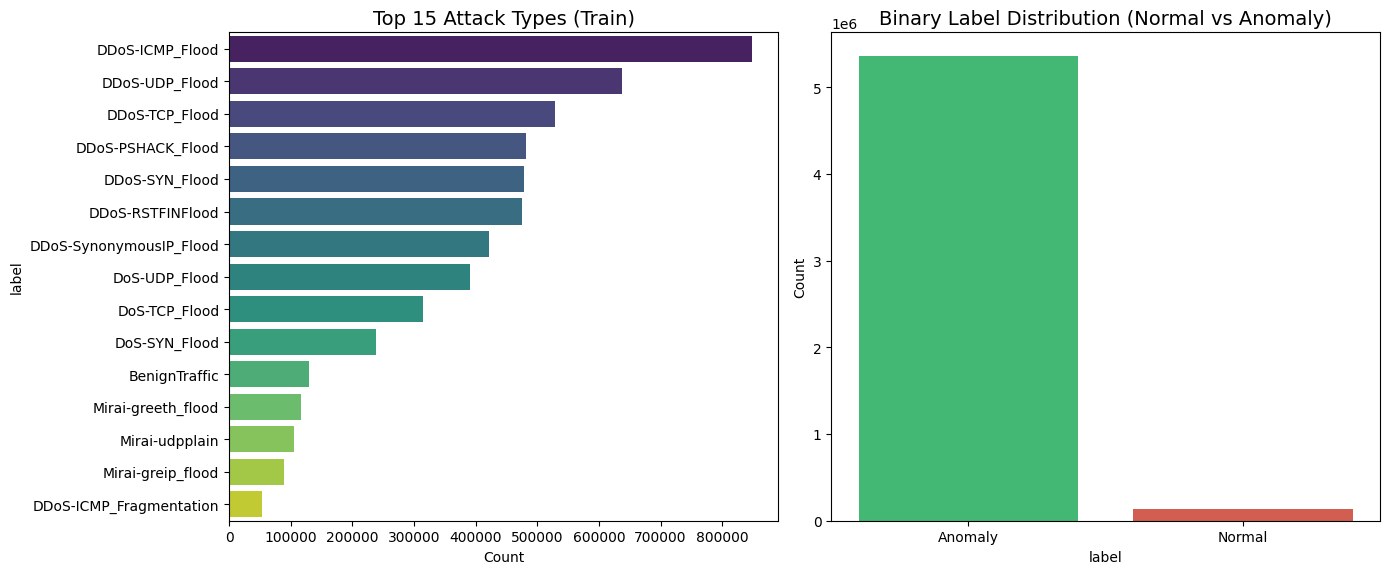


Binary Label Distribution:
label
Anomaly    5362433
Normal      129538
Name: count, dtype: int64

Percentage:
label
Anomaly    97.64
Normal      2.36
Name: count, dtype: float64


In [17]:
plt.figure(figsize=(14, 6))

# Original labels
plt.subplot(1, 2, 1)
top_labels = df_train['label'].value_counts().head(15)
sns.barplot(x=top_labels.values, y=top_labels.index, palette="viridis")
plt.title("Top 15 Attack Types (Train)", fontsize=14)
plt.xlabel("Count")

# Binary labels
plt.subplot(1, 2, 2)
binary_counts = df_train['label'].apply(
    lambda x: 'Normal' if str(x).lower() in ['benign', 'benigntraffic', 'normal'] else 'Anomaly'
).value_counts()

sns.barplot(x=binary_counts.index, y=binary_counts.values, palette=["#2ecc71", "#e74c3c"])
plt.title("Binary Label Distribution (Normal vs Anomaly)", fontsize=14)
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("\nBinary Label Distribution:")
print(binary_counts)
print("\nPercentage:")
print((binary_counts / binary_counts.sum() * 100).round(2))

In [18]:
# Statistical Summary
print("="*60)
print("STATISTICAL SUMMARY OF FEATURES")
print("="*60)
# Select numeric features only
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')

display(df_train[numeric_cols].describe().T.round(3))

STATISTICAL SUMMARY OF FEATURES


,count,mean,std,min,25%,50%,75%,max
flow_duration,5491971.0,5.657000e+00,2.749160e+02,0.000,0.000000e+00,0.000000e+00,1.050000e-01,9.943576e+04
Header_Length,5491971.0,7.687147e+04,4.615005e+05,0.000,5.400000e+01,5.400000e+01,3.001300e+02,9.890105e+06
Protocol Type,5491971.0,9.066000e+00,8.944000e+00,0.000,6.000000e+00,6.000000e+00,1.444000e+01,4.700000e+01
Duration,5491971.0,6.636100e+01,1.406500e+01,0.000,6.400000e+01,6.400000e+01,6.400000e+01,2.550000e+02
Rate,5491971.0,9.049942e+03,9.986400e+04,0.000,2.094000e+00,1.578600e+01,1.178750e+02,8.388608e+06
Srate,5491971.0,9.049942e+03,9.986400e+04,0.000,2.094000e+00,1.578600e+01,1.178750e+02,8.388608e+06
Drate,5491971.0,0.000000e+00,2.000000e-03,0.000,0.000000e+00,0.000000e+00,0.000000e+00,2.679000e+00
fin_flag_number,5491971.0,8.700000e-02,2.810000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
syn_flag_number,5491971.0,2.070000e-01,4.050000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,5491971.0,9.000000e-02,2.870000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


## Group Attacks by Category

ATTACK CATEGORY ANALYSIS - 8 CLASSES

All original labels were mapped successfully.

Distribution of 8 classes:
                   Count  Percentage (%)
attack_category                         
Normal            129538            2.36
BruteForce          1541            0.03
DDoS             3998500           72.81
DoS               950656           17.31
Mirai             309768            5.64
Recon              41617            0.76
Spoofing           57530            1.05
Web-Based           2821            0.05


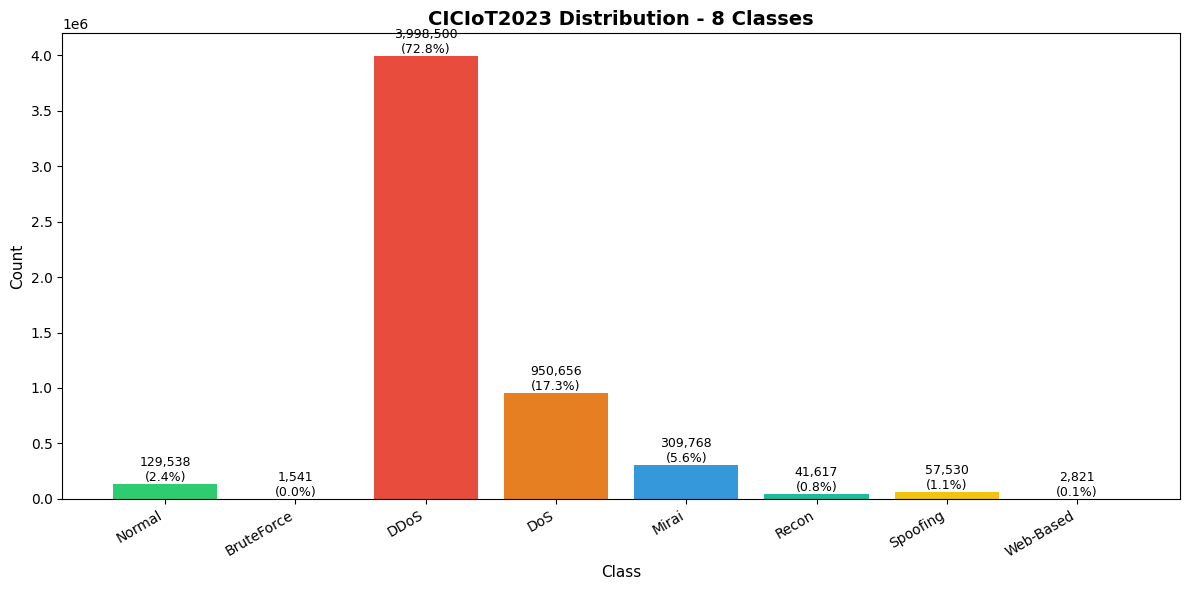


Plot saved to: plots/02_category_distribution_8_classes.png


In [19]:
# Group original labels into 8 classes

print('=' * 60)
print('ATTACK CATEGORY ANALYSIS - 8 CLASSES')
print('=' * 60)

paper_categories = [
    'Normal', 'BruteForce', 'DDoS', 'DoS',
    'Mirai', 'Recon', 'Spoofing', 'Web-Based'
]

recon_labels = {
    'Recon-HostDiscovery',
    'Recon-OSScan',
    'Recon-PortScan',
    'Recon-PingSweep',
    'VulnerabilityScan'
}

spoofing_labels = {
    'MITM-ArpSpoofing',
    'DNS_Spoofing'
}

web_labels = {
    'BrowserHijacking',
    'CommandInjection',
    'SqlInjection',
    'XSS',
    'Backdoor_Malware',
    'Uploading_Attack'
}

def map_to_8_classes(label):
    label = str(label).strip()

    if label == 'BenignTraffic':
        return 'Normal'
    if label == 'DictionaryBruteForce':
        return 'BruteForce'
    if label.startswith('DDoS-'):
        return 'DDoS'
    if label.startswith('DoS-'):
        return 'DoS'
    if label.startswith('Mirai-'):
        return 'Mirai'
    if label in recon_labels:
        return 'Recon'
    if label in spoofing_labels:
        return 'Spoofing'
    if label in web_labels:
        return 'Web-Based'

    return 'Unknown'

# Create the new 8-class column
df_train['attack_category'] = df_train['label'].map(map_to_8_classes)

# Check unmapped labels
unknown_labels = df_train.loc[df_train['attack_category'] == 'Unknown', 'label'].value_counts()

if not unknown_labels.empty:
    print('\nWARNING - Unmapped labels:')
    print(unknown_labels)
else:
    print('\nAll original labels were mapped successfully.')

# Set fixed class order
df_train['attack_category'] = pd.Categorical(df_train['attack_category'],categories=paper_categories,ordered=True)

# Count and percentage
category_counts = df_train['attack_category'].value_counts().reindex(paper_categories,fill_value=0)

category_pct = (category_counts / len(df_train) * 100).round(2)
category_summary = pd.DataFrame({'Count': category_counts,'Percentage (%)': category_pct})

print('\nDistribution of 8 classes:')
print(category_summary)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    '#2ecc71', '#8e44ad', '#e74c3c', '#e67e22',
    '#3498db', '#1abc9c', '#f1c40f', '#34495e'
]
bars = ax.bar(category_counts.index,category_counts.values,color=colors)

ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('CICIoT2023 Distribution - 8 Classes',fontsize=14,fontweight='bold')

for bar, count, pct in zip(bars, category_counts.values, category_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f'{count:,}\n({pct:.1f}%)',ha='center',va='bottom',fontsize=9)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('plots/02_category_distribution_8_classes.png',dpi=150,bbox_inches='tight')
plt.show()
print('\nPlot saved to: plots/02_category_distribution_8_classes.png')

## Class Imbalance Analysis

In [21]:
# ============================================================
# CLASS IMBALANCE ANALYSIS
# ============================================================

print("=" * 70)
print(" " * 20 + "CLASS IMBALANCE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Overall imbalance ratio
# ------------------------------------------------------------
max_count = label_counts.max()
min_count = label_counts.min()
max_class = label_counts.idxmax()
min_class = label_counts.idxmin()

imbalance_ratio = max_count / min_count

print("\n[1] OVERALL IMBALANCE")
print("-" * 70)
print(f"  • Total classes        : {len(label_counts)}")
print(f"  • Largest class        : {max_class}")
print(f"    └─ Samples           : {max_count:,}")
print(f"  • Smallest class       : {min_class}")
print(f"    └─ Samples           : {min_count:,}")
print(f"  • Imbalance ratio      : {imbalance_ratio:,.2f}:1")


# ------------------------------------------------------------
# 2. Minority classes (< 1%)
# ------------------------------------------------------------
minority_classes = label_pct[label_pct < 1].sort_values()

print("\n[2] MINORITY CLASSES (< 1%)")
print("-" * 70)
print(f"  • Number of classes    : {len(minority_classes)}")

if len(minority_classes) > 0:
    print()

    for class_name, percentage in minority_classes.items():
        count = label_counts[class_name]

        print(f"  • {class_name:<30} "f"{count:>10,} samples  "f"({percentage:>6.3f}%)")
else:
    print("  • No minority classes found.")

# ------------------------------------------------------------
# 3. Majority classes (> 10%)
# ------------------------------------------------------------
majority_classes = label_pct[label_pct > 10].sort_values(ascending=False)

print("\n[3] MAJORITY CLASSES (> 10%)")
print("-" * 70)
print(f"  • Number of classes    : {len(majority_classes)}")

if len(majority_classes) > 0:
    print()

    for class_name, percentage in majority_classes.items():
        count = label_counts[class_name]

        print(
            f"  • {class_name:<30} "
            f"{count:>10,} samples  "
            f"({percentage:>6.3f}%)"
        )
else:
    print("  • No majority classes found.")


# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------
print("\n[4] SUMMARY")
print("-" * 70)

print(
    f"  • Minority classes (<1%) : "
    f"{len(minority_classes)}"
)

print(
    f"  • Majority classes (>10%): "
    f"{len(majority_classes)}"
)

print(
    f"  • Imbalance ratio        : "
    f"{imbalance_ratio:,.2f}:1"
)
print("=" * 70)

                    CLASS IMBALANCE ANALYSIS

[1] OVERALL IMBALANCE
----------------------------------------------------------------------
  • Total classes        : 34
  • Largest class        : DDoS-ICMP_Flood
    └─ Samples           : 848,088
  • Smallest class       : Uploading_Attack
    └─ Samples           : 140
  • Imbalance ratio      : 6,057.77:1

[2] MINORITY CLASSES (< 1%)
----------------------------------------------------------------------
  • Number of classes    : 20

  • Uploading_Attack                      140 samples  ( 0.003%)
  • Recon-PingSweep                       249 samples  ( 0.005%)
  • Backdoor_Malware                      392 samples  ( 0.007%)
  • XSS                                   414 samples  ( 0.008%)
  • SqlInjection                          590 samples  ( 0.011%)
  • CommandInjection                      620 samples  ( 0.011%)
  • BrowserHijacking                      665 samples  ( 0.012%)
  • DictionaryBruteForce                1,541 samples 

## Feature Correlation Analysis

In [22]:
# Feature correlation analysis (sampled for memory efficiency)
print('='*60)
print('FEATURE CORRELATION ANALYSIS')
print('='*60)

# Sample 100k rows for correlation analysis (memory efficient)
sample_size = len(df_train)
df_sample = df_train.sample(n=sample_size, random_state=42)
print(f'\nUsing {len(df_sample):,} samples for correlation analysis')

# Select only numeric columns
numeric_cols = df_sample.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
print(f'Number of numeric features: {len(numeric_cols)}')

# Calculate correlation matrix
corr_matrix = df_sample[numeric_cols].corr()

print('\nCorrelation matrix calculated successfully!')

FEATURE CORRELATION ANALYSIS

Using 5,491,971 samples for correlation analysis
Number of numeric features: 46

Correlation matrix calculated successfully!


## Visualize Correlation Heatmap

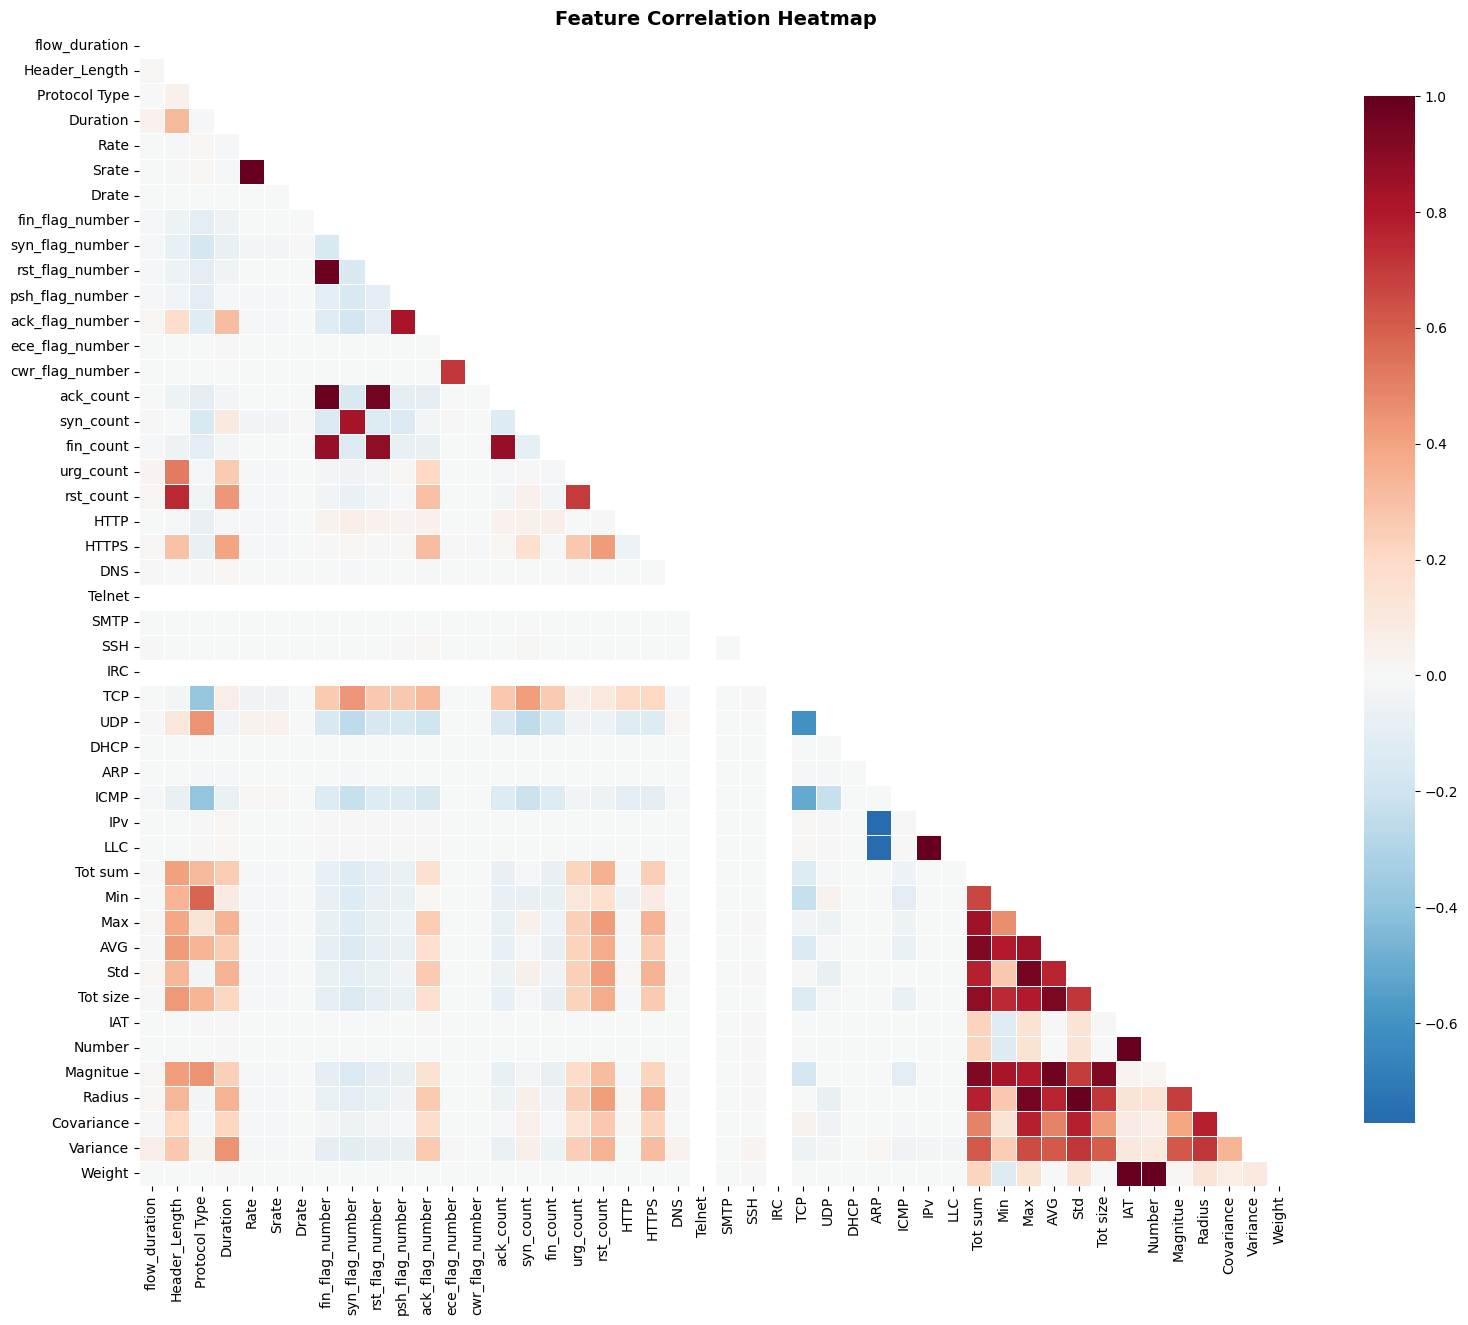


Plot saved to: plots/03_correlation_heatmap.png


In [23]:
# Visualize correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=False, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPlot saved to: plots/03_correlation_heatmap.png')

## Highly Correlated Features

In [24]:
# ============================================================
# HIGHLY CORRELATED FEATURES ANALYSIS
# ============================================================

print("=" * 75)
print(" " * 18 + "HIGHLY CORRELATED FEATURES")
print("=" * 75)

# Threshold
CORR_THRESHOLD = 0.90
# Get upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
# Collect highly correlated feature pairs
high_corr = []
for col in upper.columns:
    for row in upper.index:
        corr_value = upper.loc[row, col]
        if (pd.notna(corr_value) and abs(corr_value) > CORR_THRESHOLD):
            high_corr.append((row, col, corr_value))
# ============================================================
# RESULT
# ============================================================

if high_corr:
    # Sort by absolute correlation
    high_corr = sorted(high_corr,key=lambda x: abs(x[2]),reverse=True)
    print(
        f"\n[RESULT] Found {len(high_corr)} "
        f"highly correlated feature pairs"
    )
    print(f"[THRESHOLD] |Pearson r| > {CORR_THRESHOLD}")

    print("\n" + "-" * 75)
    print(
        f"{'Feature 1':<35} "
        f"{'Feature 2':<35} "
        f"{'Correlation':>10}"
    )
    print("-" * 75)
    # Display top 20
    for f1, f2, corr in high_corr[:20]:
        direction = "Positive" if corr > 0 else "Negative"
        print(
            f"{f1:<35} "
            f"{f2:<35} "
            f"{corr:>10.3f} "
            f"({direction})"
        )

    print("-" * 75)

    if len(high_corr) > 20:
        print(
            f"... showing top 20 of "
            f"{len(high_corr)} pairs"
        )
else:
    print(
        f"\n[RESULT] No highly correlated "
        f"feature pairs found."
    )

print("=" * 75)

                  HIGHLY CORRELATED FEATURES

[RESULT] Found 16 highly correlated feature pairs
[THRESHOLD] |Pearson r| > 0.9

---------------------------------------------------------------------------
Feature 1                           Feature 2                           Correlation
---------------------------------------------------------------------------
Rate                                Srate                                    1.000 (Positive)
IPv                                 LLC                                      1.000 (Positive)
Std                                 Radius                                   1.000 (Positive)
Number                              Weight                                   1.000 (Positive)
IAT                                 Weight                                   0.997 (Positive)
IAT                                 Number                                   0.996 (Positive)
fin_flag_number                     ack_count                            

## Feature Distribution Analysis

                    FEATURE DISTRIBUTION ANALYSIS

[INFO] Visualization sample size: 5,491,971
[INFO] Available features: 10/10

Features:
   1. flow_duration
   2. Header_Length
   3. Rate
   4. Srate
   5. Drate
   6. Tot size
   7. IAT
   8. Number
   9. Magnitue
  10. Radius


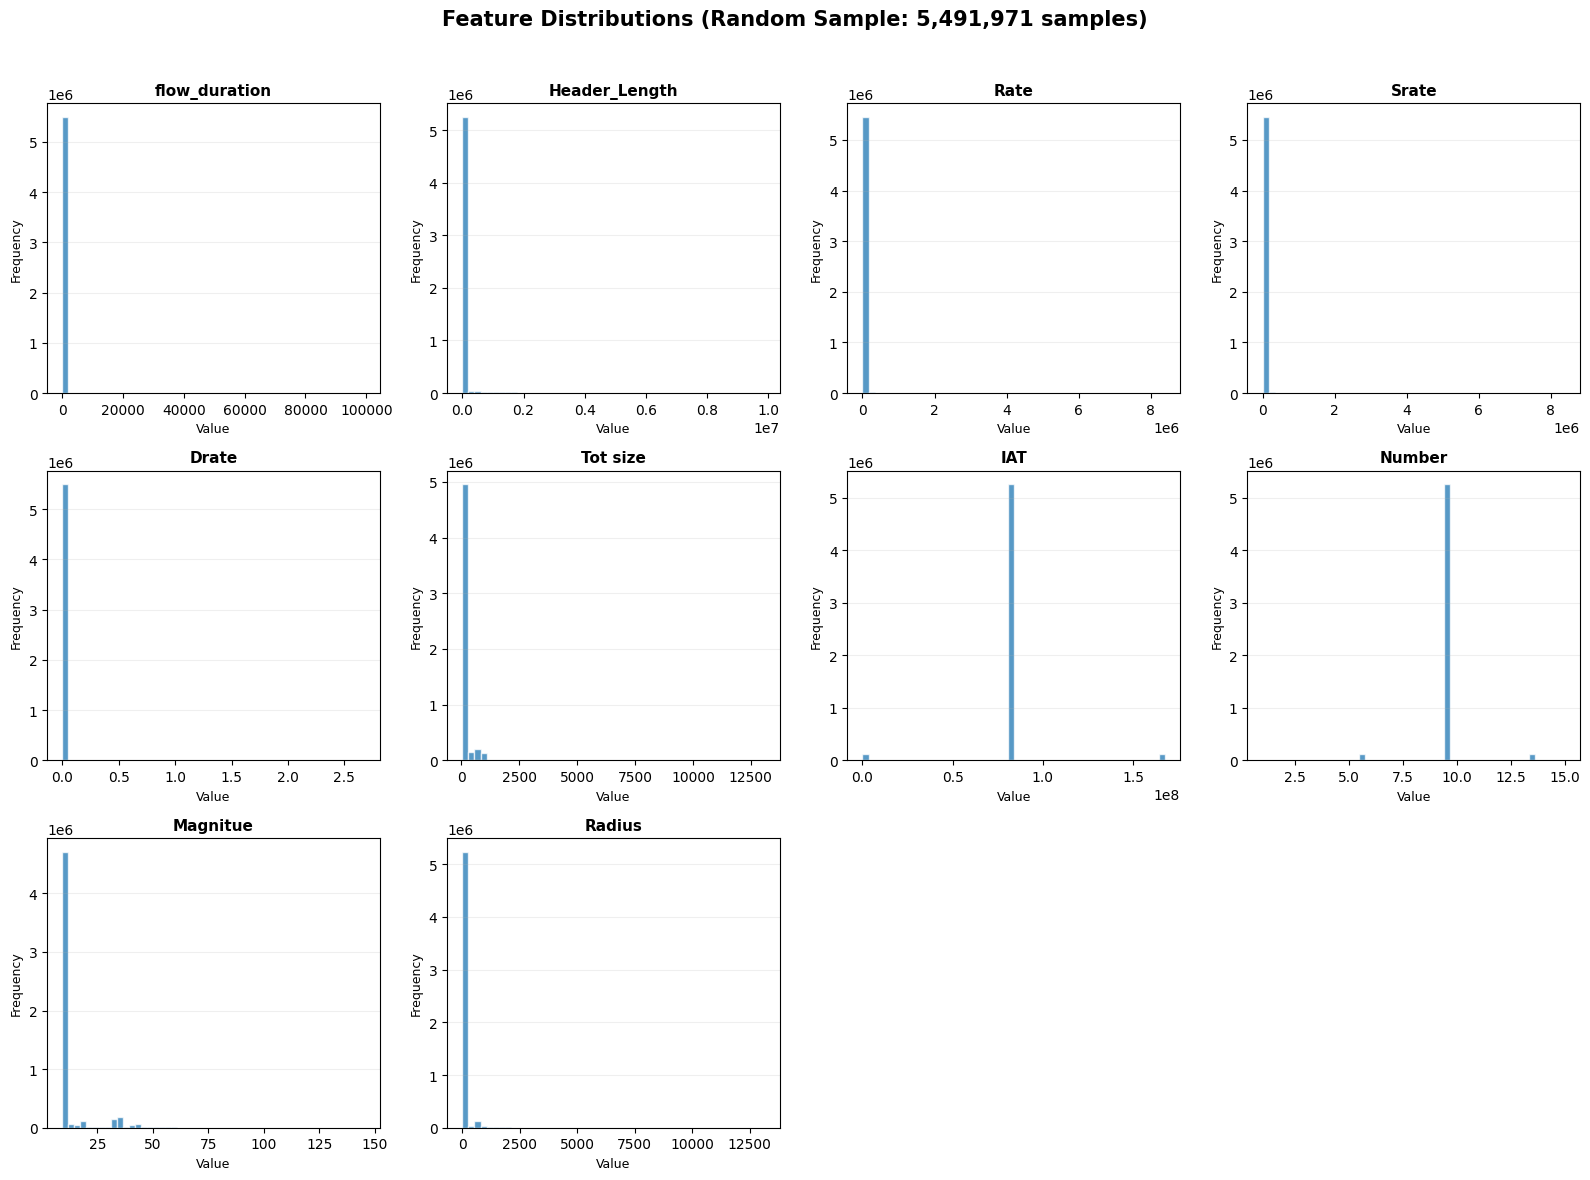


[✓] Plot saved to: plots/04_feature_distributions.png


In [28]:
# ============================================================
# FEATURE DISTRIBUTION ANALYSIS
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

print("=" * 75)
print(" " * 20 + "FEATURE DISTRIBUTION ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------
#os.makedirs("plots", exist_ok=True)

# ------------------------------------------------------------
# Sample data for visualization
# ------------------------------------------------------------
SAMPLE_SIZE = len(df_train)

sample_10k = df_train.sample(n=SAMPLE_SIZE, random_state=42)

print(f"\n[INFO] Visualization sample size: {SAMPLE_SIZE:,}")

# ------------------------------------------------------------
# Key features
# ------------------------------------------------------------
key_features = ['flow_duration', 'Header_Length', 'Rate', 'Srate', 'Drate', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius']
# Only keep features that actually exist
key_features = [f for f in key_features if f in df_train.columns]
print(
    f"[INFO] Available features: "
    f"{len(key_features)}/{10}"
)

print("\nFeatures:")
for i, feature in enumerate(key_features, 1):
    print(f"  {i:>2}. {feature}")

# ============================================================
# Create plots
# ============================================================

n_features = len(key_features)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

axes = axes.flatten()
for i, col in enumerate(key_features):
    ax = axes[i]
    data = sample_10k[col].dropna()
    # Remove infinite values
    data = data[np.isfinite(data)]
    if len(data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(data, bins=50, edgecolor='white', alpha=0.75)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.grid(axis='y', alpha=0.2)
# ------------------------------------------------------------
# Hide unused subplots
# ------------------------------------------------------------
for i in range(len(key_features), len(axes)):
    axes[i].set_visible(False)

# ------------------------------------------------------------
# Figure title
# ------------------------------------------------------------
fig.suptitle(
    f"Feature Distributions "
    f"(Random Sample: {SAMPLE_SIZE:,} samples)", 
    fontsize=15,fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# ============================================================
# Save
# ============================================================
output_path = "plots/04_feature_distributions.png"
plt.savefig(output_path,dpi=150,bbox_inches='tight')
plt.show()
print(f"\n[✓] Plot saved to: {output_path}")

In [29]:
# ============================================================
# Distribution Statistics
# ============================================================

print("\n" + "=" * 75)
print(" " * 20 + "DISTRIBUTION STATISTICS")
print("=" * 75)
stats = []
for col in key_features:
    data = sample_10k[col].dropna()
    data = data[np.isfinite(data)]
    if len(data) == 0:
        continue

    stats.append({
        'Feature': col,
        'Min': data.min(),
        'Median': data.median(),
        'Mean': data.mean(),
        'Max': data.max(),
        'Std': data.std(),
        'Skewness': data.skew()
    })

distribution_stats = pd.DataFrame(stats)
print(distribution_stats.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


                    DISTRIBUTION STATISTICS
      Feature    Min       Median         Mean           Max          Std  Skewness
flow_duration  0.000        0.000        5.657     99435.762      274.916   169.572
Header_Length  0.000       54.000    76871.467   9890104.900   461500.517     9.689
         Rate  0.000       15.786     9049.942   8388608.000    99863.997    23.260
        Srate  0.000       15.786     9049.942   8388608.000    99863.997    23.260
        Drate  0.000        0.000        0.000         2.679        0.002  1070.242
     Tot size 42.000       54.000      124.735     13098.000      241.602     5.014
          IAT  0.000 83124521.478 83194038.474 167639429.847 17065121.521     0.007
       Number  1.000        9.500        9.499        15.000        0.820    -0.058
     Magnitue  9.165       10.392       13.124       145.390        8.632     3.135
       Radius  0.000        0.000       47.220     13155.543      226.978     8.311


## Protocol Distribution Analysis

                       PROTOCOL DISTRIBUTION

[INFO] Protocol features found: 14
[INFO] Protocol features missing: 0

---------------------------------------------------------------------------
Protocol                  Mean      Usage (%)
---------------------------------------------------------------------------
LLC                     0.9999         99.99%
IPv                     0.9999         99.99%
TCP                     0.5734         57.34%
UDP                     0.2121         21.21%
ICMP                    0.1639         16.39%
HTTPS                   0.0552          5.52%
HTTP                    0.0481          4.81%
DNS                     0.0001          0.01%
ARP                     0.0001          0.01%
SSH                     0.0000          0.00%
DHCP                    0.0000          0.00%
SMTP                    0.0000          0.00%
Telnet                  0.0000          0.00%
IRC                     0.0000          0.00%
----------------------------------------

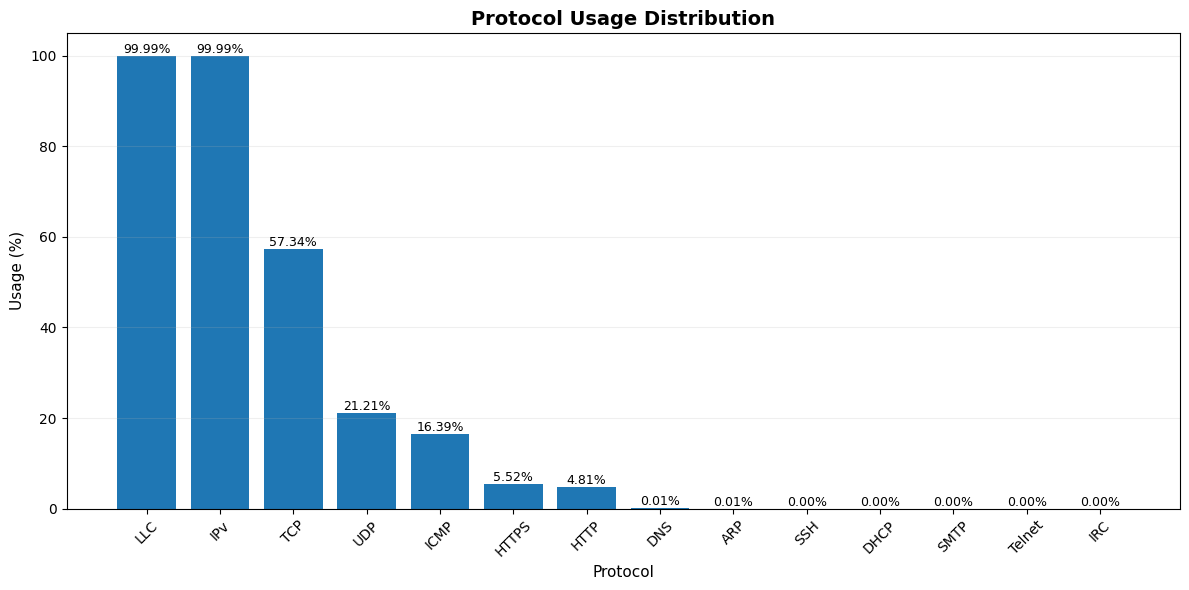


[✓] Plot saved to: plots/05_protocol_distribution.png


In [32]:
# ============================================================
# PROTOCOL DISTRIBUTION ANALYSIS
# ============================================================

import os

print("=" * 75)
print(" " * 23 + "PROTOCOL DISTRIBUTION")
print("=" * 75)

# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------
#os.makedirs("plots", exist_ok=True)

# ------------------------------------------------------------
# Protocol features
# ------------------------------------------------------------
protocol_cols = [
    'HTTP', 'HTTPS', 'DNS', 'Telnet',
    'SMTP', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP',
    'ARP', 'ICMP', 'IPv', 'LLC'
]
# Keep only existing columns
protocol_cols = [c for c in protocol_cols if c in df_train.columns]

print(f"\n[INFO] Protocol features found: {len(protocol_cols)}")
print(f"[INFO] Protocol features missing: {14 - len(protocol_cols)}")

# ============================================================
# Calculate protocol usage
# ============================================================

protocol_means = (df_train[protocol_cols].mean().sort_values(ascending=False))
protocol_percent = protocol_means * 100
# ============================================================
# Print results
# ============================================================

print("\n" + "-" * 75)
print(
    f"{'Protocol':<15}"
    f"{'Mean':>15}"
    f"{'Usage (%)':>15}"
)
print("-" * 75)

for protocol in protocol_means.index:
    mean_value = protocol_means[protocol]
    percentage = protocol_percent[protocol]
    print(
        f"{protocol:<15}"
        f"{mean_value:>15.4f}"
        f"{percentage:>14.2f}%"
    )
print("-" * 75)
# ============================================================
# Visualization
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(protocol_percent.index, protocol_percent.values)
ax.set_xlabel("Protocol", fontsize=11)
ax.set_ylabel("Usage (%)", fontsize=11)
ax.set_title("Protocol Usage Distribution", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
# Add percentage labels
for bar, value in zip(bars, protocol_percent.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.2f}%", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
# ============================================================
# Save
# ============================================================
output_path = "plots/05_protocol_distribution.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[✓] Plot saved to: {output_path}")

## Packet Flag Distribution

                    PACKET FLAG DISTRIBUTION

[INFO] Flag features found: 7

-------------------------------------------------------------------------------------
Flag                        Mean       Max            Sum       Non-Zero   Non-Zero %
-------------------------------------------------------------------------------------
fin_flag_number           0.0865         1        475,060        475,060        8.65%
syn_flag_number           0.2071         1      1,137,465      1,137,465       20.71%
rst_flag_number           0.0904         1        496,607        496,607        9.04%
psh_flag_number           0.0877         1        481,551        481,551        8.77%
ack_flag_number           0.1234         1        677,806        677,806       12.34%
ece_flag_number           0.0000         1              6              6        0.00%
cwr_flag_number           0.0000         1              3              3        0.00%
---------------------------------------------------------------

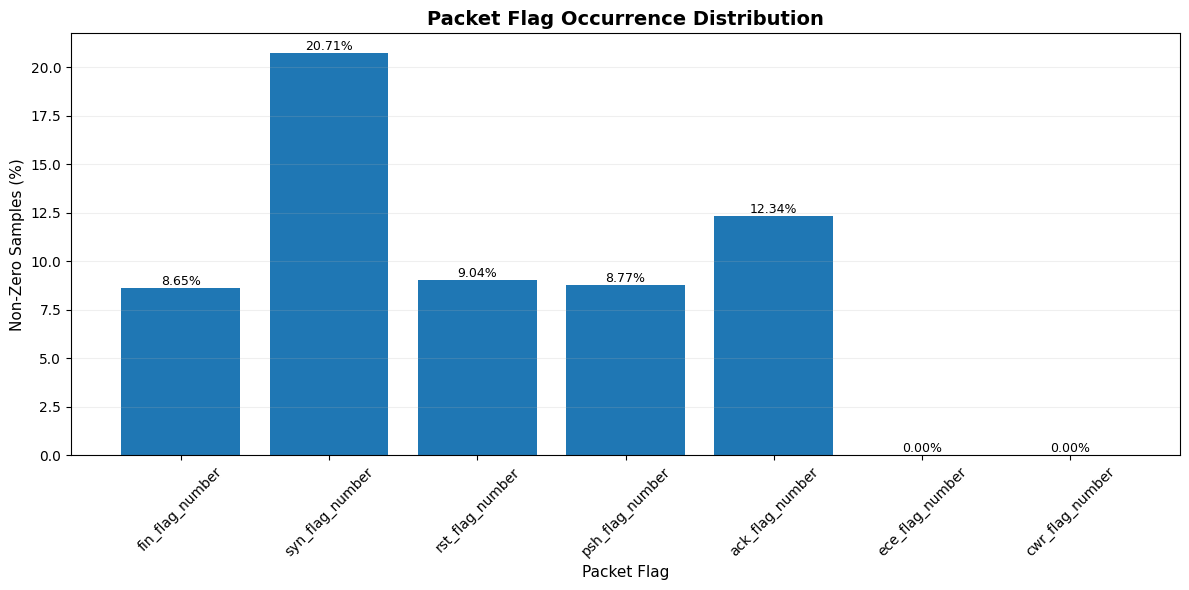


[✓] Plot saved to: plots/06_packet_flag_distribution.png


In [34]:
# ============================================================
# PACKET FLAG DISTRIBUTION ANALYSIS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 75)
print(" " * 20 + "PACKET FLAG DISTRIBUTION")
print("=" * 75)

# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------
#os.makedirs("plots", exist_ok=True)

# ------------------------------------------------------------
# Packet flag features
# ------------------------------------------------------------
flag_cols = ['fin_flag_number','syn_flag_number','rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number']
# Keep only existing columns
flag_cols = [c for c in flag_cols if c in df_train.columns]

print(f"\n[INFO] Flag features found: {len(flag_cols)}")

# ============================================================
# Calculate statistics
# ============================================================

flag_stats = pd.DataFrame({
    'Mean': df_train[flag_cols].mean(),
    'Max': df_train[flag_cols].max(),
    'Sum': df_train[flag_cols].sum(),
    'Non-Zero Count': (df_train[flag_cols] > 0).sum(),
    'Non-Zero %': (df_train[flag_cols] > 0).mean() * 100
})
# Round numeric values
flag_stats['Mean'] = flag_stats['Mean'].round(4)
flag_stats['Non-Zero %'] = flag_stats['Non-Zero %'].round(2)
# ============================================================
# Display statistics
# ============================================================
print("\n" + "-" * 85)
print(
    f"{'Flag':<20}"
    f"{'Mean':>12}"
    f"{'Max':>10}"
    f"{'Sum':>15}"
    f"{'Non-Zero':>15}"
    f"{'Non-Zero %':>13}"
)
print("-" * 85)
for flag, row in flag_stats.iterrows():
    print(
        f"{flag:<20}"
        f"{row['Mean']:>12.4f}"
        f"{row['Max']:>10.0f}"
        f"{row['Sum']:>15,.0f}"
        f"{row['Non-Zero Count']:>15,.0f}"
        f"{row['Non-Zero %']:>12.2f}%"
    )
print("-" * 85)
# ============================================================
# Visualization: Non-Zero Percentage
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
values = flag_stats['Non-Zero %']
bars = ax.bar(flag_stats.index, values)
ax.set_xlabel("Packet Flag", fontsize=11)
ax.set_ylabel("Non-Zero Samples (%)", fontsize=11)
ax.set_title("Packet Flag Occurrence Distribution", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
# Add percentage labels
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
# ============================================================
# Save
# ============================================================
output_path = "plots/06_packet_flag_distribution.png"
plt.savefig(output_path,dpi=150, bbox_inches="tight")
plt.show()
print(f"\n[✓] Plot saved to: {output_path}")

## Summary Statistics by Attack Category

In [36]:
# Feature statistics by attack category

print('=' * 60)
print('FEATURE STATISTICS BY ATTACK CATEGORY')
print('=' * 60)

compare_features = ['Rate', 'Srate', 'Drate', 'flow_duration', 'Header_Length']
compare_features = [feature for feature in compare_features if feature in df_train.columns]

# Calculate statistics separately to avoid MultiIndex errors
mean_by_category = (df_train.groupby('attack_category', observed=False)[compare_features].mean().round(2))
median_by_category = (df_train.groupby('attack_category', observed=False)[compare_features].median().round(2))
std_by_category = (df_train.groupby('attack_category', observed=False)[compare_features].std().round(2))

print('\nMean values by attack category:')
display(mean_by_category)

print('\nMedian values by attack category:')
display(median_by_category)

print('\nStandard deviation by attack category:')
display(std_by_category)

FEATURE STATISTICS BY ATTACK CATEGORY

Mean values by attack category:


,Rate,Srate,Drate,flow_duration,Header_Length
attack_category,,,,,
Normal,1962.81,1962.81,0.0,39.30,1015828.89
BruteForce,742.51,742.51,0.0,812.89,51153.64
DDoS,9053.69,9053.69,0.0,0.45,6984.58
DoS,11127.47,11127.47,0.0,1.88,9371.35
Mirai,8008.03,8008.03,0.0,1.38,524160.12
Recon,1689.11,1689.11,0.0,244.46,99834.26
Spoofing,1916.46,1916.46,0.0,169.46,1503650.56
Web-Based,2075.85,2075.85,0.0,270.98,228271.13



Median values by attack category:


,Rate,Srate,Drate,flow_duration,Header_Length
attack_category,,,,,
Normal,52.98,52.98,0.0,26.48,509333.45
BruteForce,21.95,21.95,0.0,47.90,14063.80
DDoS,13.68,13.68,0.0,0.00,54.00
DoS,11.47,11.47,0.0,0.04,108.54
Mirai,33.79,33.79,0.0,0.00,3.38
Recon,21.73,21.73,0.0,24.15,6435.20
Spoofing,96.82,96.82,0.0,8.43,572076.80
Web-Based,19.71,19.71,0.0,81.05,11752.00



Standard deviation by attack category:


,Rate,Srate,Drate,flow_duration,Header_Length
attack_category,,,,,
Normal,19931.64,19931.64,0.0,54.24,1332589.58
BruteForce,9515.21,9515.21,0.0,5813.23,110121.86
DDoS,101866.53,101866.53,0.0,86.77,47911.76
DoS,106135.92,106135.92,0.0,21.35,48594.54
Mirai,89125.38,89125.38,0.0,63.84,1072192.84
Recon,21522.81,21522.81,0.0,1872.35,331417.72
Spoofing,19240.30,19240.30,0.0,1764.07,2077839.29
Web-Based,16113.63,16113.63,0.0,435.72,825933.43


In [37]:
# ============================================================
# PHASE 1: EDA SUMMARY REPORT
# ============================================================

import numpy as np

print("=" * 75)
print(" " * 23 + "PHASE 1: EDA SUMMARY REPORT")
print("=" * 75)


# ============================================================
# 1. Dataset Overview
# ============================================================

total_rows = df_train.shape[0]
total_columns = df_train.shape[1]

memory_mb = (df_train.memory_usage(deep=True).sum() / 1024**2)

# Detect target/category columns
target_col = 'label' if 'label' in df_train.columns else None
category_col = 'category' if 'category' in df_train.columns else None

feature_columns = [c for c in df_train.columns if c not in [target_col, category_col]]
num_features = len(feature_columns)

# ============================================================
# 2. Data Quality
# ============================================================

missing_values = df_train.isnull().sum().sum()

duplicate_rows = df_train.duplicated().sum()

numeric_df = df_train.select_dtypes(include=[np.number])

infinite_values = np.isinf(numeric_df).sum().sum()
# ============================================================
# 3. Target Statistics
# ============================================================

if target_col:

    num_classes = len(label_counts)

    max_class = label_counts.idxmax()
    min_class = label_counts.idxmin()

    max_percentage = label_pct[max_class]
    min_percentage = label_pct[min_class]

else:

    num_classes = 0
    max_class = "N/A"
    min_class = "N/A"
    max_percentage = 0
    min_percentage = 0


# ============================================================
# 4. Print Report
# ============================================================

print(f"""
DATASET OVERVIEW
---------------------------------------------------------------------------
   Total Rows              : {total_rows:,}
   Total Columns           : {total_columns}
   Numerical Features      : {num_features}
   Memory Usage             : {memory_mb:.2f} MB
""")


print(f"""
DATA QUALITY
---------------------------------------------------------------------------
   Missing Values           : {missing_values:,}
   Duplicate Rows           : {duplicate_rows:,}
   Infinite Values          : {infinite_values:,}
""")


print(f"""
TARGET VARIABLE
---------------------------------------------------------------------------
   Unique Attack Types      : {num_classes}
   Imbalance Ratio          : {imbalance_ratio:,.2f}:1
   Majority Class           : {max_class}
                              ({max_percentage:.2f}%)
   Minority Class           : {min_class}
                              ({min_percentage:.2f}%)
   Minority Classes (<1%)   : {len(minority_classes)}
""")


# ============================================================
# 5. Attack Categories
# ============================================================

print("""
ATTACK CATEGORIES
---------------------------------------------------------------------------""")

for category, count in category_counts.items():

    percentage = category_pct[category]

    print(
        f"   {str(category):<20}"
        f": {count:>12,} "
        f"({percentage:>6.2f}%)"
    )


# ============================================================
# 6. Key Findings
# ============================================================

print("""
KEY FINDINGS
---------------------------------------------------------------------------""")

findings = [
    f"Dataset contains {total_rows:,} samples "
    f"across {num_classes} attack types.",

    f"Class imbalance ratio is "
    f"{imbalance_ratio:,.2f}:1.",

    f"{len(minority_classes)} attack classes "
    f"represent less than 1% of the dataset.",

    f"{len(majority_classes)} attack classes "
    f"represent more than 10% of the dataset.",

    f"{duplicate_rows:,} duplicate rows were detected.",

    f"{infinite_values:,} infinite numerical values "
    f"were detected.",

    "Feature correlation should be investigated "
    "before model training.",

    "Protocol and packet-flag features provide "
    "useful traffic-level information."
]

for i, finding in enumerate(findings, 1):

    print(f"   {i}. {finding}")


# ============================================================
# 7. Next Steps
# ============================================================

print("""
NEXT STEPS
---------------------------------------------------------------------------

   Phase 2: Data Preprocessing

   -> Handle missing values
   -> Handle infinite values
   -> Analyze and remove redundant features if justified
   -> Encode target labels
   -> Train/Test split with stratification
   -> Apply appropriate feature scaling
   -> Address class imbalance
   -> Prepare data for model training
""")


# ============================================================
# 8. Generated Plots
# ============================================================

print("""
GENERATED PLOTS
---------------------------------------------------------------------------

   [01] plots/01_class_distribution.png
   [02] plots/02_category_distribution.png
   [03] plots/03_correlation_heatmap.png
   [04] plots/04_feature_distributions.png
   [05] plots/05_protocol_distribution.png
   [06] plots/06_packet_flag_distribution.png
""")


print("=" * 75)
print(" " * 24 + "PHASE 1 COMPLETED")
print("=" * 75)

                       PHASE 1: EDA SUMMARY REPORT

DATASET OVERVIEW
---------------------------------------------------------------------------
   Total Rows              : 5,491,971
   Total Columns           : 48
   Numerical Features      : 47
   Memory Usage             : 2270.09 MB


DATA QUALITY
---------------------------------------------------------------------------
   Missing Values           : 0
   Duplicate Rows           : 134,565
   Infinite Values          : 0


TARGET VARIABLE
---------------------------------------------------------------------------
   Unique Attack Types      : 34
   Imbalance Ratio          : 6,057.77:1
   Majority Class           : DDoS-ICMP_Flood
                              (15.44%)
   Minority Class           : Uploading_Attack
                              (0.00%)
   Minority Classes (<1%)   : 20


ATTACK CATEGORIES
---------------------------------------------------------------------------
   Normal              :      129,538 (  2.36%)
   

## Save Processed Data (Optional)

In [ ]:
# Save processed data for next phase
# Uncomment if you want to save

# import joblib

# print('Saving processed data...')
# joblib.dump(df_train, 'processed_data.pkl')
# print('Data saved to processed_data.pkl')

# #Or save as parquet for better compression
# df.to_parquet('processed_data.parquet', index=False)
# print('Data saved to processed_data.parquet')

# print('To save data, uncomment the code above')